1: Cài đặt và Kết nối (Môi trường)

In [1]:
# 1. Kết nối Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Cài đặt thư viện timm
!pip install timm

# 3. Import các thư viện cần thiết
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import timm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import numpy as np

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Mounted at /content/drive
Đang sử dụng thiết bị: cuda


2: Giải nén dữ liệu

In [2]:
# Giải nén file từ Drive vào bộ nhớ tạm của Colab
!unzip -q "/content/drive/MyDrive/Colab_Notebooks/archive(1).zip" -d /content/plant_data

# Kiểm tra thư mục
!ls /content/plant_data/PlantVillage

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


3: Chuẩn bị DataLoader (Tiền xử lý)

In [3]:
data_dir = "/content/plant_data/PlantVillage"

# Transform chuẩn cho ảnh đầu vào (224x224)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)

# Chia tập dữ liệu 70/15/15
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

class_names = full_dataset.classes
print(f"Số lượng lớp bệnh: {len(class_names)}")

Số lượng lớp bệnh: 15


4: Hàm huấn luyện

In [4]:
def train_model_with_history(model, model_name, epochs=20):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n--- BẮT ĐẦU HUẤN LUYỆN: {model_name} ---")
    for epoch in range(1, epochs + 1):
        # Phase Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Phase Validation
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()

        val_loss = v_loss / len(val_loader)
        val_acc = v_correct / v_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch}/{epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%}")

    return model, history

5: Huấn luyện 3 Mô hình

In [5]:
# 1. Huấn luyện MobileNetV2
model_mobilenet = timm.create_model('mobilenetv2_100', pretrained=True)
model_mobilenet.classifier = nn.Linear(model_mobilenet.classifier.in_features, len(class_names))
model_mobilenet, history_mobile = train_model_with_history(model_mobilenet, "MobileNetV2", epochs=20)
plot_history(history_mobile, "MobileNetV2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]


--- BẮT ĐẦU HUẤN LUYỆN: MobileNetV2 ---
Epoch 1/20 | Loss: 0.7043 | Acc: 82.47% | Val Acc: 97.71%
Epoch 2/20 | Loss: 0.1224 | Acc: 96.59% | Val Acc: 98.61%
Epoch 3/20 | Loss: 0.0657 | Acc: 98.19% | Val Acc: 99.29%
Epoch 4/20 | Loss: 0.0473 | Acc: 98.72% | Val Acc: 99.16%
Epoch 5/20 | Loss: 0.0350 | Acc: 99.04% | Val Acc: 99.55%
Epoch 6/20 | Loss: 0.0256 | Acc: 99.29% | Val Acc: 99.42%
Epoch 7/20 | Loss: 0.0217 | Acc: 99.40% | Val Acc: 99.29%
Epoch 8/20 | Loss: 0.0181 | Acc: 99.54% | Val Acc: 99.61%
Epoch 9/20 | Loss: 0.0159 | Acc: 99.52% | Val Acc: 99.71%
Epoch 10/20 | Loss: 0.0148 | Acc: 99.56% | Val Acc: 99.48%
Epoch 11/20 | Loss: 0.0103 | Acc: 99.70% | Val Acc: 99.48%
Epoch 12/20 | Loss: 0.0133 | Acc: 99.59% | Val Acc: 99.32%
Epoch 13/20 | Loss: 0.0102 | Acc: 99.74% | Val Acc: 99.64%
Epoch 14/20 | Loss: 0.0107 | Acc: 99.68% | Val Acc: 99.58%
Epoch 15/20 | Loss: 0.0093 | Acc: 99.72% | Val Acc: 99.52%
Epoch 16/20 | Loss: 0.0092 | Acc: 99.74% | Val Acc: 99.81%
Epoch 17/20 | Loss: 0.00

NameError: name 'plot_history' is not defined

In [6]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'b-o', label='Val Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'r-o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'b-o', label='Val Acc')
    plt.title(f'Accuracy - {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

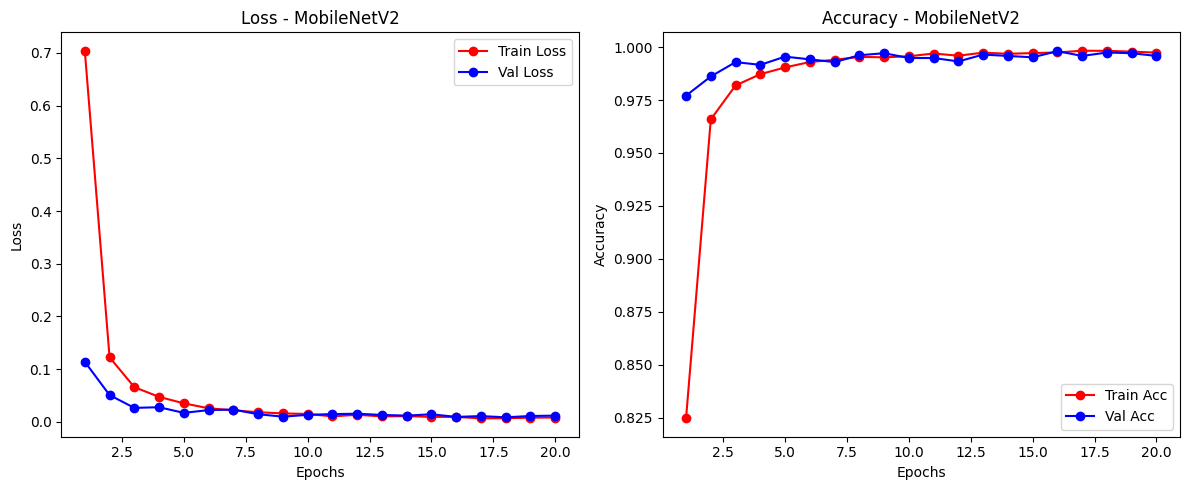

In [7]:
# Vẽ biểu đồ cho MobileNet đã train xong
plot_history(history_mobile, "MobileNetV2")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


--- BẮT ĐẦU HUẤN LUYỆN: ResNet50 ---
Epoch 1/20 | Loss: 1.4603 | Acc: 57.81% | Val Acc: 93.05%
Epoch 2/20 | Loss: 0.2223 | Acc: 93.89% | Val Acc: 97.67%
Epoch 3/20 | Loss: 0.1035 | Acc: 97.10% | Val Acc: 98.68%
Epoch 4/20 | Loss: 0.0707 | Acc: 97.93% | Val Acc: 98.58%
Epoch 5/20 | Loss: 0.0527 | Acc: 98.47% | Val Acc: 99.10%
Epoch 6/20 | Loss: 0.0364 | Acc: 98.97% | Val Acc: 99.16%
Epoch 7/20 | Loss: 0.0291 | Acc: 99.16% | Val Acc: 99.42%
Epoch 8/20 | Loss: 0.0249 | Acc: 99.27% | Val Acc: 99.48%
Epoch 9/20 | Loss: 0.0183 | Acc: 99.49% | Val Acc: 99.45%
Epoch 10/20 | Loss: 0.0181 | Acc: 99.50% | Val Acc: 99.58%
Epoch 11/20 | Loss: 0.0146 | Acc: 99.58% | Val Acc: 99.45%
Epoch 12/20 | Loss: 0.0132 | Acc: 99.62% | Val Acc: 99.32%
Epoch 13/20 | Loss: 0.0117 | Acc: 99.70% | Val Acc: 99.58%
Epoch 14/20 | Loss: 0.0108 | Acc: 99.72% | Val Acc: 99.61%
Epoch 15/20 | Loss: 0.0110 | Acc: 99.67% | Val Acc: 99.68%
Epoch 16/20 | Loss: 0.0103 | Acc: 99.72% | Val Acc: 99.58%
Epoch 17/20 | Loss: 0.0082 

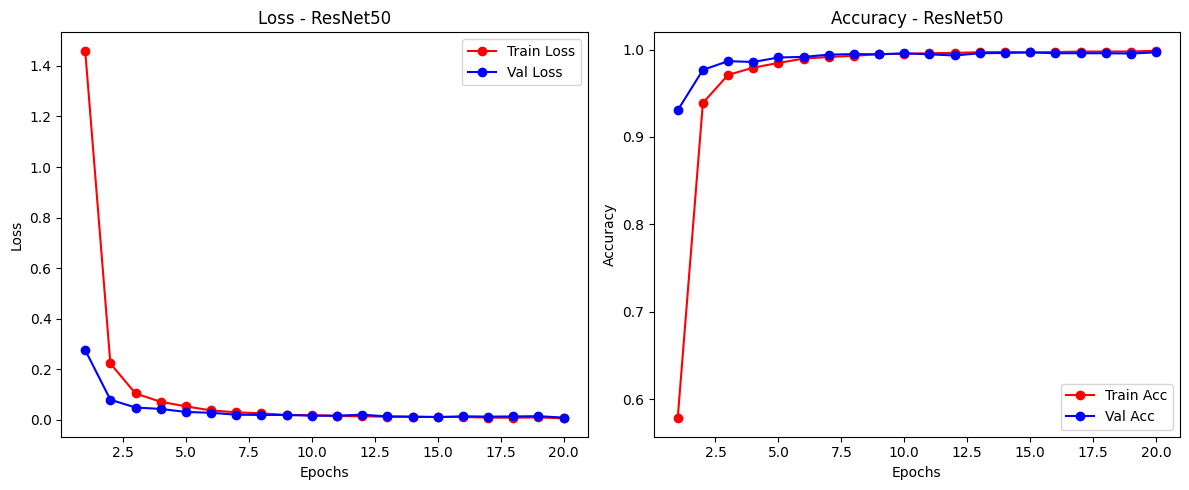

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


--- BẮT ĐẦU HUẤN LUYỆN: EfficientNet-B0 ---
Epoch 1/20 | Loss: 0.4909 | Acc: 88.09% | Val Acc: 99.03%
Epoch 2/20 | Loss: 0.0667 | Acc: 98.14% | Val Acc: 99.19%
Epoch 3/20 | Loss: 0.0367 | Acc: 98.94% | Val Acc: 99.61%
Epoch 4/20 | Loss: 0.0210 | Acc: 99.36% | Val Acc: 99.48%
Epoch 5/20 | Loss: 0.0168 | Acc: 99.60% | Val Acc: 99.61%
Epoch 6/20 | Loss: 0.0138 | Acc: 99.59% | Val Acc: 99.48%
Epoch 7/20 | Loss: 0.0164 | Acc: 99.52% | Val Acc: 99.13%
Epoch 8/20 | Loss: 0.0118 | Acc: 99.66% | Val Acc: 99.87%
Epoch 9/20 | Loss: 0.0121 | Acc: 99.69% | Val Acc: 99.74%
Epoch 10/20 | Loss: 0.0101 | Acc: 99.66% | Val Acc: 99.77%
Epoch 11/20 | Loss: 0.0109 | Acc: 99.70% | Val Acc: 99.77%
Epoch 12/20 | Loss: 0.0079 | Acc: 99.77% | Val Acc: 99.71%
Epoch 13/20 | Loss: 0.0078 | Acc: 99.76% | Val Acc: 99.77%
Epoch 14/20 | Loss: 0.0062 | Acc: 99.83% | Val Acc: 99.64%
Epoch 15/20 | Loss: 0.0092 | Acc: 99.72% | Val Acc: 99.68%
Epoch 16/20 | Loss: 0.0072 | Acc: 99.81% | Val Acc: 99.90%
Epoch 17/20 | Loss: 

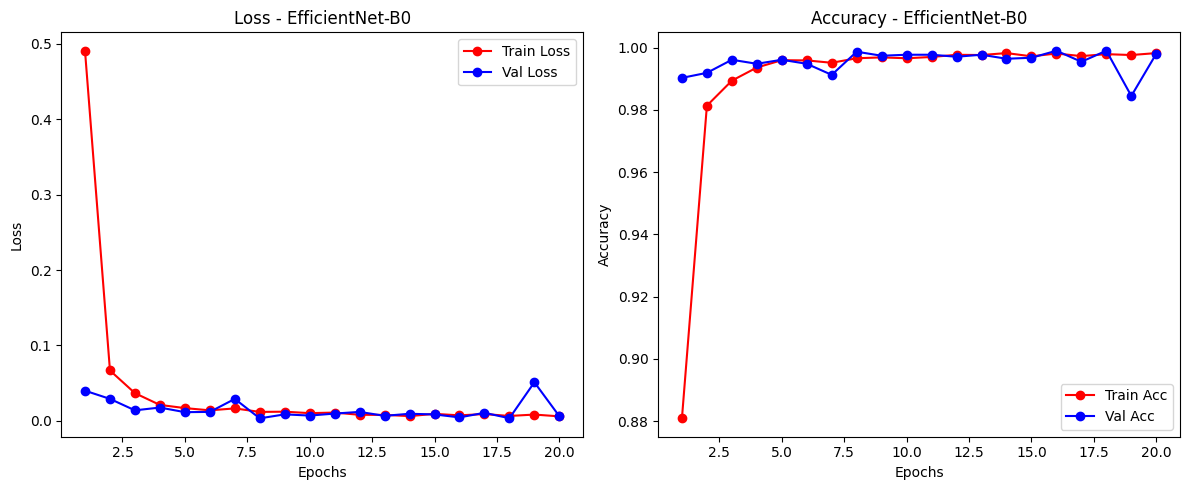

In [8]:
# 2. Huấn luyện ResNet50 (Chạy tiếp từ đây)
model_resnet = timm.create_model('resnet50', pretrained=True)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, len(class_names))
model_resnet, history_resnet = train_model_with_history(model_resnet, "ResNet50", epochs=20)
plot_history(history_resnet, "ResNet50")

# 3. Huấn luyện EfficientNet-B0
model_effnet = timm.create_model('efficientnet_b0', pretrained=True)
model_effnet.classifier = nn.Linear(model_effnet.classifier.in_features, len(class_names))
model_effnet, history_effnet = train_model_with_history(model_effnet, "EfficientNet-B0", epochs=20)
plot_history(history_effnet, "EfficientNet-B0")

6: Đánh giá chi tiết (Confusion Matrix & Final Accuracy)

📊 Đang đánh giá MobileNetV2...


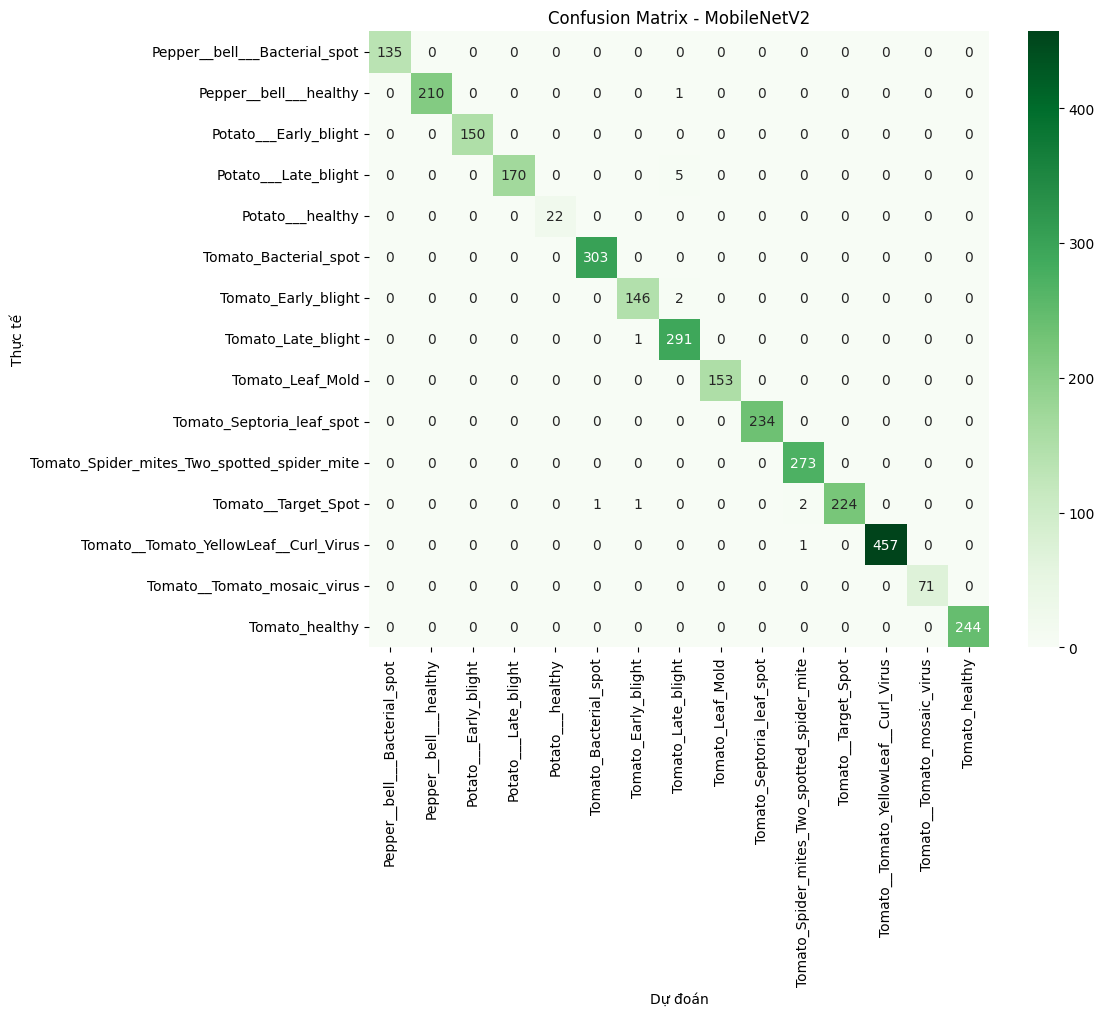

📊 Đang đánh giá ResNet50...


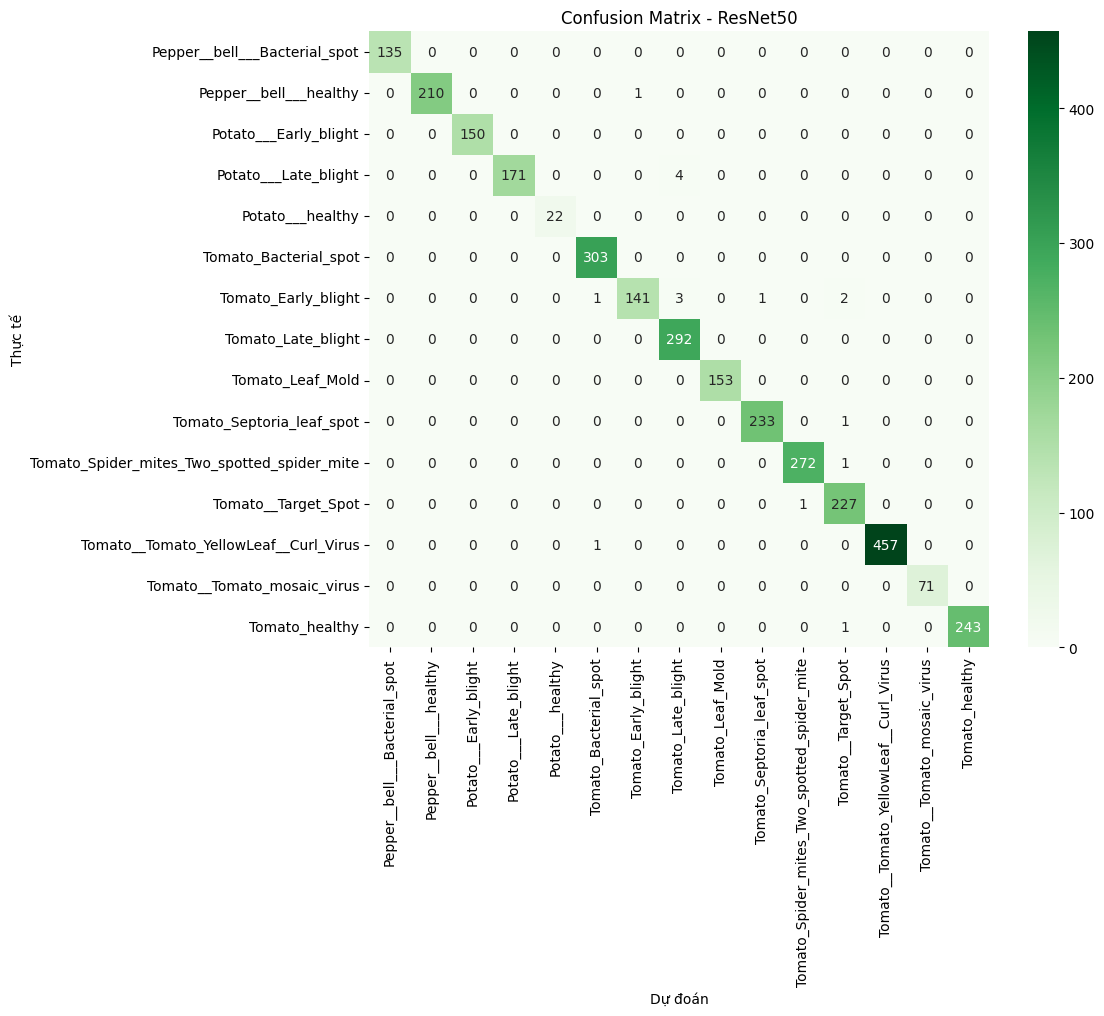

📊 Đang đánh giá EfficientNet-B0...


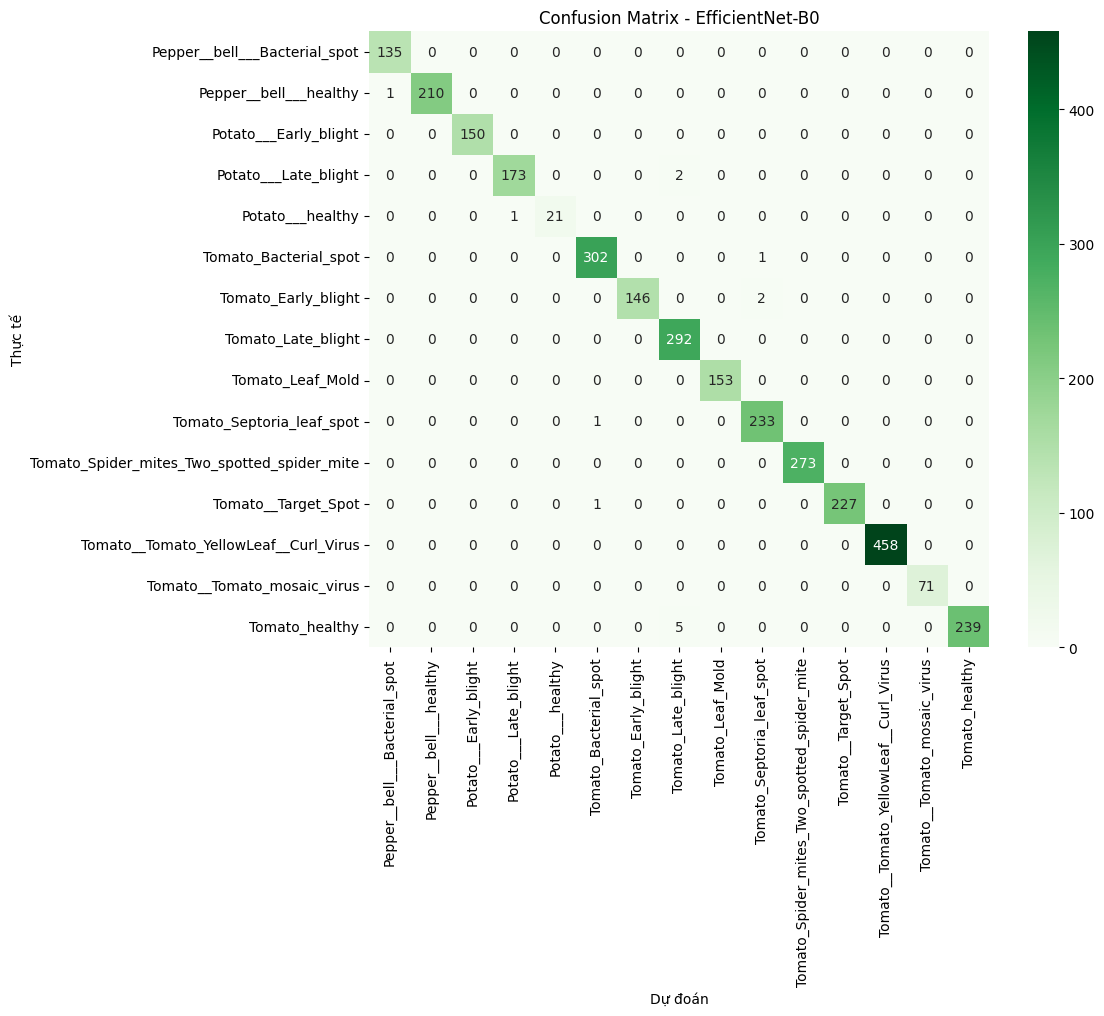


Mô hình              | Accuracy     | F1-Score    
------------------------------------------------------------
MobileNetV2          | 99.55%       | 99.55%      
ResNet50             | 99.45%       | 99.45%      
EfficientNet-B0      | 99.55%       | 99.55%      


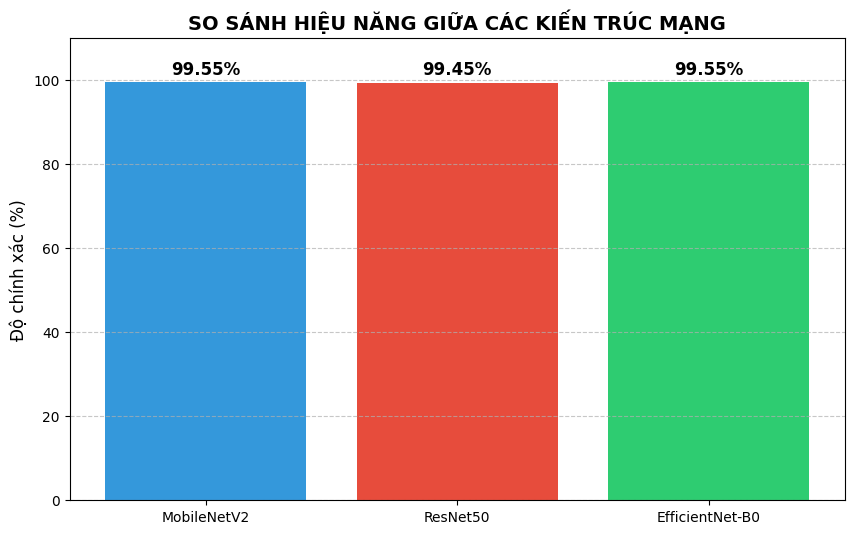

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import pandas as pd

# 1. Hàm đánh giá chi tiết từng mô hình
def detailed_eval(model, loader, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Tính toán chỉ số
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Vẽ Confusion Matrix (Ma trận nhầm lẫn)
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

    return acc, f1

# 2. Chạy đánh giá và lưu kết quả vào danh sách
results = []

print("📊 Đang đánh giá MobileNetV2...")
acc_m, f1_m = detailed_eval(model_mobilenet, test_loader, "MobileNetV2")
results.append(['MobileNetV2', acc_m, f1_m])

print("📊 Đang đánh giá ResNet50...")
acc_r, f1_r = detailed_eval(model_resnet, test_loader, "ResNet50")
results.append(['ResNet50', acc_r, f1_r])

print("📊 Đang đánh giá EfficientNet-B0...")
acc_e, f1_e = detailed_eval(model_effnet, test_loader, "EfficientNet-B0")
results.append(['EfficientNet-B0', acc_e, f1_e])

# 3. In BẢNG TỔNG HỢP CUỐI CÙNG
print("\n" + "="*60)
print(f"{'Mô hình':<20} | {'Accuracy':<12} | {'F1-Score':<12}")
print("-" * 60)
for res in results:
    print(f"{res[0]:<20} | {res[1]:<12.2%} | {res[2]:<12.2%}")
print("="*60)

# 4. Vẽ BIỂU ĐỒ CỘT SO SÁNH
names = [r[0] for r in results]
accs = [r[1] * 100 for r in results]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, accs, color=['#3498db', '#e74c3c', '#2ecc71'])

# Thêm số liệu trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 110)
plt.ylabel('Độ chính xác (%)', fontsize=12)
plt.title('SO SÁNH HIỆU NĂNG GIỮA CÁC KIẾN TRÚC MẠNG', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

7: Lưu và Tải về (Để làm Streamlit)

In [10]:
torch.save(model_mobilenet.state_dict(), "mobilenet_model.pth")
torch.save(model_resnet.state_dict(), "resnet50_model.pth")
torch.save(model_effnet.state_dict(), "efficientnet_model.pth")

from google.colab import files
files.download("mobilenet_model.pth")
files.download("resnet50_model.pth")
files.download("efficientnet_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>